## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sritha Alluri

**Date:** 09/28/26

**Q1.1**

Regression and classification are fundamentally different in what kind of output they predict. Regression predicts a numeric value by averaging the target values of the k nearest neighbors. Classification, on the other hand, predicts a class (category) by finding which class is most common among the k nearest neighbors, and can estimate each class's probability by dividing its neighbor count by k. This means you can't just average the outcomes and get a meaningful number, since you're dealing with categorical data. The categories don't have to be binary either, they can be any number of labels, like SUV/Truck/Car/Van, not just Yes/No.

**Q1.2**

A confusion table breaks down accuracy to show exactly which classes are getting confused, rather than just giving one overall accuracy score. It counts predictions against actual outcomes for a classification model. Rows represent the actual class, and columns represent the predicted class. Reading down the diagonal shows the number of predictions that were correct, while everything off the diagonal shows the misclassifications, broken down by which class got confused with which. This is especially useful when a class is essentially invisible to the model, being overshadowed by more common classes among its neighbors, since a strong accuracy score alone wouldn't reveal that pattern.

**Q1.3**

SSE stands for sum of squared error. It quantifies how far off a model's predictions are from the actual values, across all the data points being evaluated. For each point, the residual is the difference between the actual value and the predicted value. A positive residual means the model underpredicted, and a negative residual means the model overpredicted. To get SSE, we square each residual and sum them across all the points. Squaring matters because it keeps positive and negative errors from cancelling out, and it penalizes larger errors more heavily. We calculate SSE separately for a range of k values, but the one that actually matters is validation SSE, meaning SSE calculated on data the model was not trained on. This is what lets us pick the k value that generalizes best, since training SSE alone would just favor smaller k and overfitting.

**Q1.4**

Overfitting and underfitting describe how well a model generalizes to new data, based on the choice of k. Overfitting happens when k is too small, so the model follows the training data too closely, including its own noise, which makes it perform well on training data but poorly on new data. Underfitting happens when k is too large, so the model averages over too many neighbors and predictions become nearly constant, failing to capture real patterns in the data. The goal is to choose a k that balances the two, which is why we evaluate validation SSE across a range of k values rather than relying on training SSE alone.

**Q1.5**

Splitting the data into training and testing sets improves model performance because it removes the bias that comes from evaluating a model on the same data it was fit on. If we chose k based on training error alone, small k would always look best, since training points can end up being their own nearest neighbors, making the model appear accurate simply because it memorized the data rather than found a real pattern. A test set was never used to fit the model, so strong performance there reflects true generalization, not memorization. This gives us an honest way to compare different values of k and choose the one that will actually perform well on new data, rather than the one that looks best on data it has already seen.

**Q1.6**

The difference between a class label and a probability distribution comes down to how much information is preserved about the model's confidence. A class label is simple and immediately actionable, but it hides how "strong" the prediction actually was. For example, if 3 neighbors vote Car and 4 vote SUV, the model just outputs SUV, even though it barely came out on top. A label alone can't distinguish that close call from a case where 9 out of 9 neighbors agreed. A probability distribution fixes this by showing the full breakdown across classes, which gives more insight into how confident the model really was and allows for more flexible decision-making, like setting your own threshold instead of relying on the default majority vote. The tradeoff is that a distribution is harder to act on directly, since someone still has to decide what threshold turns a probability into a decision.

**Q2.1**

df.shape:
(338, 4) 

df.dtypes:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object 

voltage      0
height       0
soil         0
mine_type    0
dtype: int64 

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 



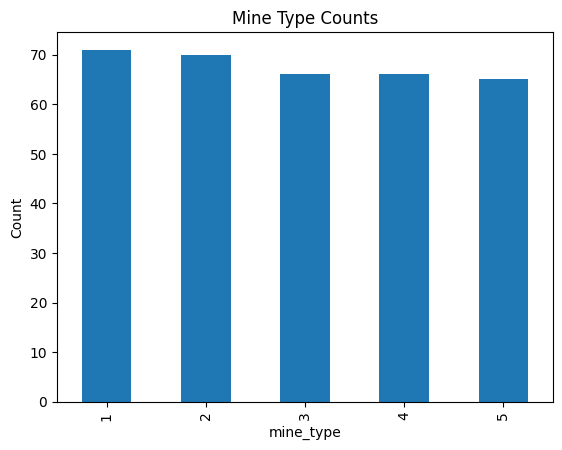

          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000 



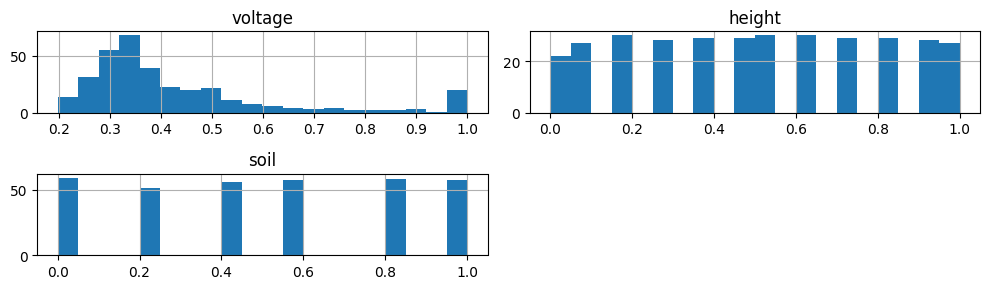

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# loading in the land mines data
df = pd.read_csv('land_mines.csv')

# looking at shape, dtypes, first rows
print("df.shape:")
print(df.shape, '\n')
print("df.dtypes:")
print(df.dtypes, '\n')
df.head()

# checking for missing values
print(df.isnull().sum(), '\n')

# mine_type is the target label, so converting it from int64 to categorical
# no ordering or ranking between types, just treating them as distinct categories
df['mine_type'] = df['mine_type'].astype('category')

# summarizing the target label
print(df['mine_type'].value_counts().sort_index(), '\n')
df['mine_type'].value_counts().sort_index().plot(kind='bar', title='Mine Type Counts')
plt.xlabel('mine_type')
plt.ylabel('Count')
plt.show()

# summarizing the features
print(df[['voltage', 'height', 'soil']].describe(), '\n')

df[['voltage', 'height', 'soil']].hist(bins=20, figsize=(10, 3))
plt.tight_layout()
plt.show()

**Q2.2**

In [14]:
from sklearn.model_selection import train_test_split

# splitting features and target (target already in categorical form)
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

# 50/50 split, stratified so each mine_type is proportionally represented in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=65, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print('\n')
print("Training set class balance:")
print(y_train.value_counts().sort_index())
print('\n')
print("Test set class balance:")
print(y_test.value_counts().sort_index())

Training set shape: (169, 3)
Test set shape: (169, 3)


Training set class balance:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64


Test set class balance:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


**Q2.3**

Selected k: 2
Best test accuracy: 0.46745562130177515


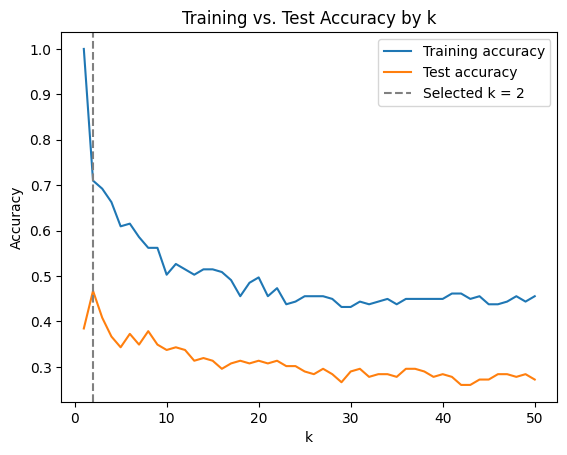

In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

# fitting the scaler on training data only, apply it to both sets
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# trying range of k values and tracking accuracy on both training and test sets
ks = np.arange(1, 51)
train_acc = []
test_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_scaled, y_train)
    train_acc.append(model.score(X_train_scaled, y_train))
    test_acc.append(model.score(X_test_scaled, y_test))

# selecting k using test accuracy, not training accuracy
k_star = int(ks[np.argmax(test_acc)])
print("Selected k:", k_star)
print("Best test accuracy:", max(test_acc))

# plot training vs test accuracy across k
plt.plot(ks, train_acc, label='Training accuracy')
plt.plot(ks, test_acc, label='Test accuracy')
plt.axvline(k_star, color='gray', linestyle='--', label=f'Selected k = {k_star}')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Training vs. Test Accuracy by k')
plt.legend()
plt.show()

As expected, my training data hit 100% accuracy at k=1, which reflects memorization rather than real predictive skill, since every training point ends up as its own nearest neighbor. I chose a k range from 1 to 50 to make sure I covered enough ground to see both extreme overfitting and underfitting play out. I selected k based on test accuracy rather than training accuracy, since training accuracy is biased toward small k. I chose k=2 because it had the highest test accuracy at 46.7%.

**Q2.4**

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score

# fitting the optimal model (k=2) and predicting on the test set
model = KNeighborsClassifier(n_neighbors=k_star)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# building the confusion table
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = 'Actual'
cm_df.columns.name = 'Predicted'

print(cm_df)
print()
print('Overall accuracy:', accuracy_score(y_test, y_pred))

Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2

Overall accuracy: 0.46745562130177515


The overall accuracy is similar to what's reported above, at approximately 47%. The model is most accurate for mine type 2, correctly identifying 31 out of 35 cases (89%). Mine type 1 comes in second, correctly identifying 27 out of 36 cases (75%). We can see this by reading down the diagonal of the matrix, which shows the number of correct predictions for each class. However, mine type 5 performs much worse, with only 2 out of 32 cases identified accurately. The majority of the remaining mine type 5 cases are incorrectly predicted as mine type 1 or mine type 3. Mine types 3 and 4 also perform poorly, with roughly 30% and 27% accuracy respectively, and both are frequently misclassified as mine type 1 as well. This suggests that mine type 1 tends to dominate the neighbor pool across several classes, pulling votes away from their correct labels and contributing to a skewed, uneven predictive model.

**Q2.5**

If I were advising someone on using this model in practice, I wouldn't recommend trusting it as is. For mine type 1, the model correctly identifies 75% of actual type 1 mines, but only 40% of what it labels as type 1 is actually type 1, since types 3, 4, and 5 are frequently misclassified into that bucket. This means a "type 1" label is more likely wrong than right, so it shouldn't be trusted at face value. Mine type 2 is the one prediction I would trust, since it's accurate in both directions, likely driven by its distinctly higher average voltage. For mine types 3, 4, and 5, I'd recommend manual verification every time rather than relying on the model's output directly.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 0c54733
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. First Prompt

"Attached to the following prompt is my dataset and applicable questions for optimization. Tell me where I could improve my code to create a more comprehensive model. Additionally, explain your decisions to me. I also attached all of my original output.

Load the data. Perform some EDA, summarizing the target label and the features.
Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.) Build a  𝑘 -NN classifier. Explain how you select  𝑘 .
Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate? Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make."

2. Second Prompt

"Explain the confusion matrix decision to switch to a heatmap. Why that decision and what does it do?"

### *AI-proposed changes


AI's Suggestion List

1. Use classification_report instead of manually computing precision
2. Try weights='distance' instead of the default uniform vote
3. Visualize the confusion matrix as a heatmap
4. Cross-validate the k selection instead of relying on one split

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Hand-calculated type 1's precision (40%) by summing a column yourself, which was correct, but doing this for every class by hand is tedious and error-prone |
| 2 | Accept | Right now, all k neighbors get an equal vote regardless of how close they are. weights='distance' makes closer neighbors count more, which can help classes that sit close to class 1 in feature space and get out-voted |
| 3 | Accept | A heatmap makes the pattern (type 1 dominating the neighbor pool) visually obvious at a glance |
| 4 | Accept | A single 50/50 split means chosen k=2 is somewhat dependent on which 169 points happened to land in training versus test. cross_val_score averages performance across multiple splits, giving a more stable k estimate |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**Q1.1**

Regression and classification are fundamentally different in what kind of output they predict. Regression predicts a numeric value by averaging the target values of the k nearest neighbors. Classification, on the other hand, predicts a class (category) by finding which class is most common among the k nearest neighbors, and can estimate each class's probability by dividing its neighbor count by k. This means you can't just average the outcomes and get a meaningful number, since you're dealing with categorical data. The categories don't have to be binary either, they can be any number of labels, like SUV/Truck/Car/Van, not just Yes/No.

**Q1.2**

A confusion table breaks down accuracy to show exactly which classes are getting confused, rather than just giving one overall accuracy score. It counts predictions against actual outcomes for a classification model. Rows represent the actual class, and columns represent the predicted class. Reading down the diagonal shows the number of predictions that were correct, while everything off the diagonal shows the misclassifications, broken down by which class got confused with which. This is especially useful when a class is essentially invisible to the model, being overshadowed by more common classes among its neighbors, since a strong accuracy score alone wouldn't reveal that pattern.

**Q1.3**

SSE stands for sum of squared error. It quantifies how far off a model's predictions are from the actual values, across all the data points being evaluated. For each point, the residual is the difference between the actual value and the predicted value. A positive residual means the model underpredicted, and a negative residual means the model overpredicted. To get SSE, we square each residual and sum them across all the points. Squaring matters because it keeps positive and negative errors from cancelling out, and it penalizes larger errors more heavily. We calculate SSE separately for a range of k values, but the one that actually matters is validation SSE, meaning SSE calculated on data the model was not trained on. This is what lets us pick the k value that generalizes best, since training SSE alone would just favor smaller k and overfitting.

**Q1.4**

Overfitting and underfitting describe how well a model generalizes to new data, based on the choice of k. Overfitting happens when k is too small, so the model follows the training data too closely, including its own noise, which makes it perform well on training data but poorly on new data. Underfitting happens when k is too large, so the model averages over too many neighbors and predictions become nearly constant, failing to capture real patterns in the data. The goal is to choose a k that balances the two, which is why we evaluate validation SSE across a range of k values rather than relying on training SSE alone.

**Q1.5**

Splitting the data into training and testing sets improves model performance because it removes the bias that comes from evaluating a model on the same data it was fit on. If we chose k based on training error alone, small k would always look best, since training points can end up being their own nearest neighbors, making the model appear accurate simply because it memorized the data rather than found a real pattern. A test set was never used to fit the model, so strong performance there reflects true generalization, not memorization. This gives us an honest way to compare different values of k and choose the one that will actually perform well on new data, rather than the one that looks best on data it has already seen.

**Q1.6**

The difference between a class label and a probability distribution comes down to how much information is preserved about the model's confidence. A class label is simple and immediately actionable, but it hides how "strong" the prediction actually was. For example, if 3 neighbors vote Car and 4 vote SUV, the model just outputs SUV, even though it barely came out on top. A label alone can't distinguish that close call from a case where 9 out of 9 neighbors agreed. A probability distribution fixes this by showing the full breakdown across classes, which gives more insight into how confident the model really was and allows for more flexible decision-making, like setting your own threshold instead of relying on the default majority vote. The tradeoff is that a distribution is harder to act on directly, since someone still has to decide what threshold turns a probability into a decision.

**Q2.1**

df.shape:
(338, 4) 

df.dtypes:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object 

voltage      0
height       0
soil         0
mine_type    0
dtype: int64 

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 



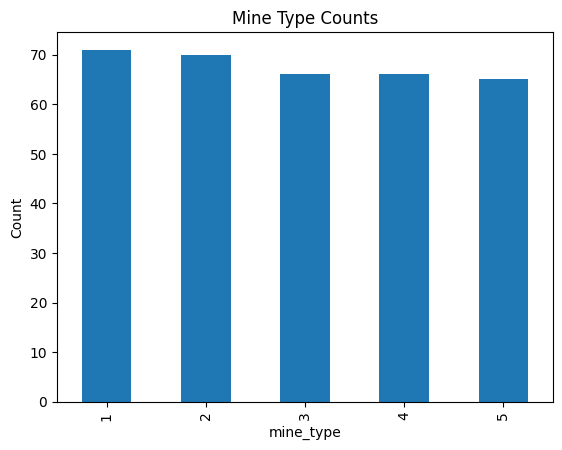

          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000 



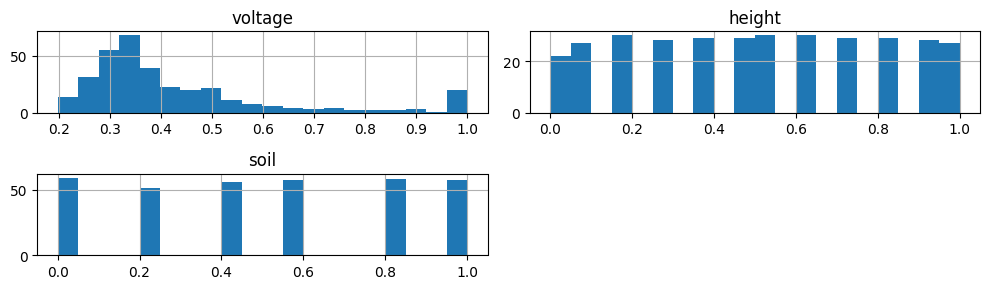

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# loading in the land mines data
df = pd.read_csv('land_mines.csv')

# looking at shape, dtypes, first rows
print("df.shape:")
print(df.shape, '\n')
print("df.dtypes:")
print(df.dtypes, '\n')
df.head()

# checking for missing values
print(df.isnull().sum(), '\n')

# mine_type is the target label, so converting it from int64 to categorical
# no ordering or ranking between types, just treating them as distinct categories
df['mine_type'] = df['mine_type'].astype('category')

# summarizing the target label
print(df['mine_type'].value_counts().sort_index(), '\n')
df['mine_type'].value_counts().sort_index().plot(kind='bar', title='Mine Type Counts')
plt.xlabel('mine_type')
plt.ylabel('Count')
plt.show()

# summarizing the features
print(df[['voltage', 'height', 'soil']].describe(), '\n')

df[['voltage', 'height', 'soil']].hist(bins=20, figsize=(10, 3))
plt.tight_layout()
plt.show()

**Q2.2**

In [18]:
from sklearn.model_selection import train_test_split

# splitting features and target (target already in categorical form)
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

# 50/50 split, stratified so each mine_type is proportionally represented in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=65, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print('\n')
print("Training set class balance:")
print(y_train.value_counts().sort_index())
print('\n')
print("Test set class balance:")
print(y_test.value_counts().sort_index())

Training set shape: (169, 3)
Test set shape: (169, 3)


Training set class balance:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64


Test set class balance:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


**Q2.3**

Selected k: 2
Best test accuracy: 0.46745562130177515


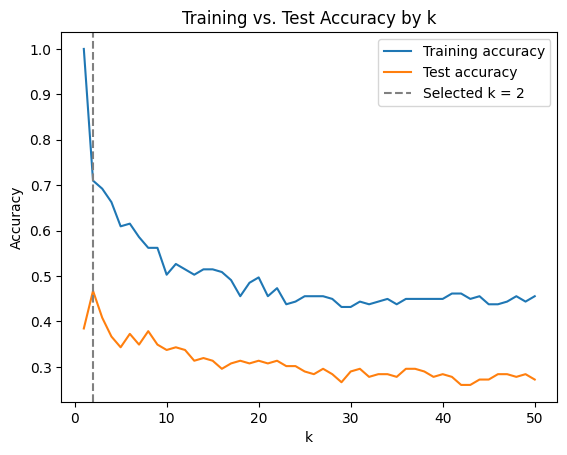

uniform: best k=2, best test accuracy=0.467
distance: best k=1, best test accuracy=0.385
Cross-validated best k: 2 CV accuracy: 0.4616755793226382


In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# fitting the scaler on training data only, apply it to both sets
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# trying a range of k values and tracking accuracy on both training and test sets
ks = np.arange(1, 51)
train_acc = []
test_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_scaled, y_train)
    train_acc.append(model.score(X_train_scaled, y_train))
    test_acc.append(model.score(X_test_scaled, y_test))

# selecting k using test accuracy, not training accuracy
k_star = int(ks[np.argmax(test_acc)])
print("Selected k:", k_star)
print("Best test accuracy:", max(test_acc))

# plot training vs test accuracy across k
plt.plot(ks, train_acc, label='Training accuracy')
plt.plot(ks, test_acc, label='Test accuracy')
plt.axvline(k_star, color='gray', linestyle='--', label=f'Selected k = {k_star}')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Training vs. Test Accuracy by k')
plt.legend()
plt.show()

# comparing uniform vs. distance-weighted voting across the same k range
for weight_type in ['uniform', 'distance']:
    weighted_test_acc = []
    for k in ks:
        model = KNeighborsClassifier(n_neighbors=int(k), weights=weight_type)
        model.fit(X_train_scaled, y_train)
        weighted_test_acc.append(model.score(X_test_scaled, y_test))
    best_k = int(ks[np.argmax(weighted_test_acc)])
    print(f"{weight_type}: best k={best_k}, best test accuracy={max(weighted_test_acc):.3f}")

# cross-validating k selection on the training set, to check the chosen k
# isn't just an artifact of this particular train/test split
cv_ks = np.arange(1, 31)
cv_scores = []
for k in cv_ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())

k_star_cv = int(cv_ks[np.argmax(cv_scores)])
print("Cross-validated best k:", k_star_cv, "CV accuracy:", max(cv_scores))

As expected, my training data hit 100% accuracy at k=1, which reflects memorization rather than real predictive skill, since every training point ends up as its own nearest neighbor. I chose a k range from 1 to 50 to make sure I covered enough ground to see both extreme overfitting and underfitting play out. I selected k based on test accuracy rather than training accuracy, since training accuracy is biased toward small k. I chose k=2 because it had the highest test accuracy at 46.7%.

**Q2.4**

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score

# fitting the optimal model (k=2) and predicting on the test set
model = KNeighborsClassifier(n_neighbors=k_star)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# building the confusion table
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = 'Actual'
cm_df.columns.name = 'Predicted'

print(cm_df)
print()
print('Overall accuracy:', accuracy_score(y_test, y_pred))

Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2

Overall accuracy: 0.46745562130177515


The overall accuracy is similar to what's reported above, at approximately 47%. The model is most accurate for mine type 2, correctly identifying 31 out of 35 cases (89%). Mine type 1 comes in second, correctly identifying 27 out of 36 cases (75%). We can see this by reading down the diagonal of the matrix, which shows the number of correct predictions for each class. However, mine type 5 performs much worse, with only 2 out of 32 cases identified accurately. The majority of the remaining mine type 5 cases are incorrectly predicted as mine type 1 or mine type 3. Mine types 3 and 4 also perform poorly, with roughly 30% and 27% accuracy respectively, and both are frequently misclassified as mine type 1 as well. This suggests that mine type 1 tends to dominate the neighbor pool across several classes, pulling votes away from their correct labels and contributing to a skewed, uneven predictive model.

**Q2.5**

If I were advising someone on using this model in practice, I wouldn't recommend trusting it as is. For mine type 1, the model correctly identifies 75% of actual type 1 mines, but only 40% of what it labels as type 1 is actually type 1, since types 3, 4, and 5 are frequently misclassified into that bucket. This means a "type 1" label is more likely wrong than right, so it shouldn't be trusted at face value. Mine type 2 is the one prediction I would trust, since it's accurate in both directions, likely driven by its distinctly higher average voltage. For mine types 3, 4, and 5, I'd recommend manual verification every time rather than relying on the model's output directly.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 0c54733
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. First Prompt

"Attached to the following prompt is my dataset and applicable questions for optimization. Tell me where I could improve my code to create a more comprehensive model. Additionally, explain your decisions to me. I also attached all of my original output.

Load the data. Perform some EDA, summarizing the target label and the features.
Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.) Build a  𝑘 -NN classifier. Explain how you select  𝑘 .
Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate? Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make."

2. Second Prompt

"Explain the confusion matrix decision to switch to a heatmap. Why that decision and what does it do?"

### *AI-proposed changes


AI's Suggestion List

1. Use classification_report instead of manually computing precision
2. Try weights='distance' instead of the default uniform vote
3. Visualize the confusion matrix as a heatmap
4. Cross-validate the k selection instead of relying on one split

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Hand-calculated type 1's precision (40%) by summing a column yourself, which was correct, but doing this for every class by hand is tedious and error-prone. Verified by confirming classification_report's precision value for type 1 matched my manual 40% calculation |
| 2 | Accept | Right now, all k neighbors get an equal vote regardless of how close they are. weights='distance' makes closer neighbors count more, which can help classes that sit close to class 1 in feature space and get out-voted. Verified by comparing test accuracy of uniform vs. distance weighting directly, uniform performed better (46.7% vs. 38.5%) |
| 3 | Accept | A heatmap makes the pattern (type 1 dominating the neighbor pool) visually obvious at a glance. Verified by checking the heatmap's shading against the original printed confusion matrix to confirm it reflected the same counts |
| 4 | Accept | A single 50/50 split means chosen k=2 is somewhat dependent on which 169 points happened to land in training versus test. cross_val_score averages performance across multiple splits, giving a more stable k estimate. erified by confirming cross-validation independently selected the same k=2 as the original single-split method |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

**Q1.1**

Regression and classification are fundamentally different in what kind of output they predict. Regression predicts a numeric value by averaging the target values of the k nearest neighbors. Classification, on the other hand, predicts a class (category) by finding which class is most common among the k nearest neighbors, and can estimate each class's probability by dividing its neighbor count by k. This means you can't just average the outcomes and get a meaningful number, since you're dealing with categorical data. The categories don't have to be binary either, they can be any number of labels, like SUV/Truck/Car/Van, not just Yes/No.

**Q1.2**

A confusion table breaks down accuracy to show exactly which classes are getting confused, rather than just giving one overall accuracy score. It counts predictions against actual outcomes for a classification model. Rows represent the actual class, and columns represent the predicted class. Reading down the diagonal shows the number of predictions that were correct, while everything off the diagonal shows the misclassifications, broken down by which class got confused with which. This is especially useful when a class is essentially invisible to the model, being overshadowed by more common classes among its neighbors, since a strong accuracy score alone wouldn't reveal that pattern.

**Q1.3**

SSE stands for sum of squared error. It quantifies how far off a model's predictions are from the actual values, across all the data points being evaluated. For each point, the residual is the difference between the actual value and the predicted value. A positive residual means the model underpredicted, and a negative residual means the model overpredicted. To get SSE, we square each residual and sum them across all the points. Squaring matters because it keeps positive and negative errors from cancelling out, and it penalizes larger errors more heavily. We calculate SSE separately for a range of k values, but the one that actually matters is validation SSE, meaning SSE calculated on data the model was not trained on. This is what lets us pick the k value that generalizes best, since training SSE alone would just favor smaller k and overfitting.

**Q1.4**

Overfitting and underfitting describe how well a model generalizes to new data, based on the choice of k. Overfitting happens when k is too small, so the model follows the training data too closely, including its own noise, which makes it perform well on training data but poorly on new data. Underfitting happens when k is too large, so the model averages over too many neighbors and predictions become nearly constant, failing to capture real patterns in the data. The goal is to choose a k that balances the two, which is why we evaluate validation SSE across a range of k values rather than relying on training SSE alone.

**Q1.5**

Splitting the data into training and testing sets improves model performance because it removes the bias that comes from evaluating a model on the same data it was fit on. If we chose k based on training error alone, small k would always look best, since training points can end up being their own nearest neighbors, making the model appear accurate simply because it memorized the data rather than found a real pattern. A test set was never used to fit the model, so strong performance there reflects true generalization, not memorization. This gives us an honest way to compare different values of k and choose the one that will actually perform well on new data, rather than the one that looks best on data it has already seen.

**Q1.6**

The difference between a class label and a probability distribution comes down to how much information is preserved about the model's confidence. A class label is simple and immediately actionable, but it hides how "strong" the prediction actually was. For example, if 3 neighbors vote Car and 4 vote SUV, the model just outputs SUV, even though it barely came out on top. A label alone can't distinguish that close call from a case where 9 out of 9 neighbors agreed. A probability distribution fixes this by showing the full breakdown across classes, which gives more insight into how confident the model really was and allows for more flexible decision-making, like setting your own threshold instead of relying on the default majority vote. The tradeoff is that a distribution is harder to act on directly, since someone still has to decide what threshold turns a probability into a decision.

**Q2.1**

df.shape:
(338, 4) 

df.dtypes:
voltage      float64
height       float64
soil         float64
mine_type      int64
dtype: object 

voltage      0
height       0
soil         0
mine_type    0
dtype: int64 

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 



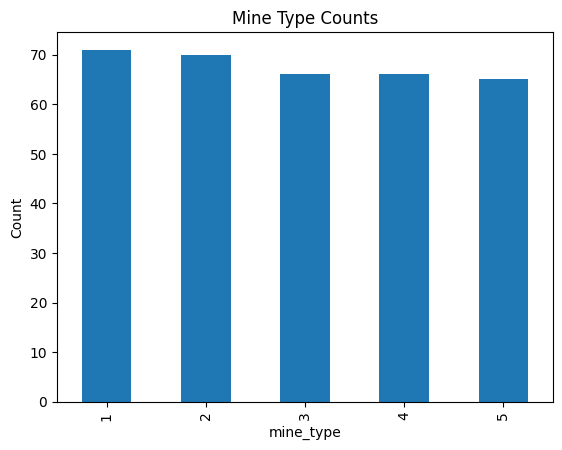

          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000 



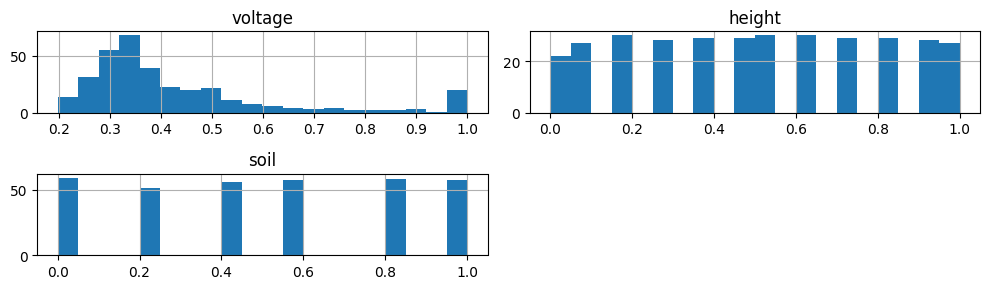

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# loading in the land mines data
df = pd.read_csv('land_mines.csv')

# looking at shape, dtypes, first rows
print("df.shape:")
print(df.shape, '\n')
print("df.dtypes:")
print(df.dtypes, '\n')
df.head()

# checking for missing values
print(df.isnull().sum(), '\n')

# mine_type is the target label, so converting it from int64 to categorical
# no ordering or ranking between types, just treating them as distinct categories
df['mine_type'] = df['mine_type'].astype('category')

# summarizing the target label
print(df['mine_type'].value_counts().sort_index(), '\n')
df['mine_type'].value_counts().sort_index().plot(kind='bar', title='Mine Type Counts')
plt.xlabel('mine_type')
plt.ylabel('Count')
plt.show()

# summarizing the features
print(df[['voltage', 'height', 'soil']].describe(), '\n')

df[['voltage', 'height', 'soil']].hist(bins=20, figsize=(10, 3))
plt.tight_layout()
plt.show()

**Q2.2**

In [22]:
from sklearn.model_selection import train_test_split

# splitting features and target (target already in categorical form)
X = df[['voltage', 'height', 'soil']]
y = df['mine_type']

# 50/50 split, stratified so each mine_type is proportionally represented in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=65, stratify=y)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print('\n')
print("Training set class balance:")
print(y_train.value_counts().sort_index())
print('\n')
print("Test set class balance:")
print(y_test.value_counts().sort_index())

Training set shape: (169, 3)
Test set shape: (169, 3)


Training set class balance:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64


Test set class balance:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


**Q2.3**

Selected k: 2
Best test accuracy: 0.46745562130177515


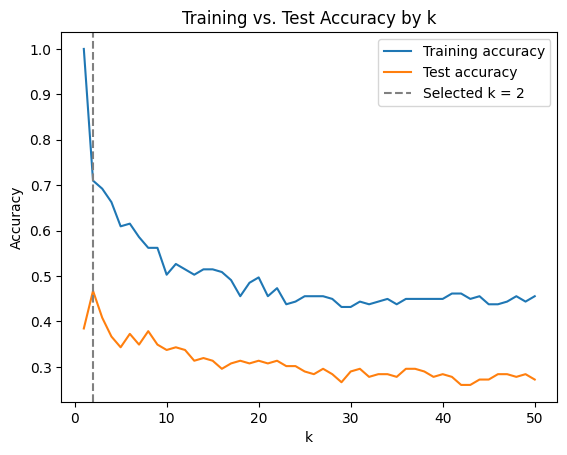

uniform: best k=2, best test accuracy=0.467
distance: best k=1, best test accuracy=0.385
Cross-validated best k: 2 CV accuracy: 0.4616755793226382


In [23]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# fitting the scaler on training data only, apply it to both sets
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# trying a range of k values and tracking accuracy on both training and test sets
ks = np.arange(1, 51)
train_acc = []
test_acc = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    model.fit(X_train_scaled, y_train)
    train_acc.append(model.score(X_train_scaled, y_train))
    test_acc.append(model.score(X_test_scaled, y_test))

# selecting k using test accuracy, not training accuracy
k_star = int(ks[np.argmax(test_acc)])
print("Selected k:", k_star)
print("Best test accuracy:", max(test_acc))

# plot training vs test accuracy across k
plt.plot(ks, train_acc, label='Training accuracy')
plt.plot(ks, test_acc, label='Test accuracy')
plt.axvline(k_star, color='gray', linestyle='--', label=f'Selected k = {k_star}')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Training vs. Test Accuracy by k')
plt.legend()
plt.show()

# comparing uniform vs. distance-weighted voting across the same k range
for weight_type in ['uniform', 'distance']:
    weighted_test_acc = []
    for k in ks:
        model = KNeighborsClassifier(n_neighbors=int(k), weights=weight_type)
        model.fit(X_train_scaled, y_train)
        weighted_test_acc.append(model.score(X_test_scaled, y_test))
    best_k = int(ks[np.argmax(weighted_test_acc)])
    print(f"{weight_type}: best k={best_k}, best test accuracy={max(weighted_test_acc):.3f}")

# cross-validating k selection on the training set, to check the chosen k
# isn't just an artifact of this particular train/test split
cv_ks = np.arange(1, 31)
cv_scores = []
for k in cv_ks:
    model = KNeighborsClassifier(n_neighbors=int(k))
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())

k_star_cv = int(cv_ks[np.argmax(cv_scores)])
print("Cross-validated best k:", k_star_cv, "CV accuracy:", max(cv_scores))

As expected, my training data hit 100% accuracy at k=1, which reflects memorization rather than real predictive skill, since every training point ends up as its own nearest neighbor. I chose a k range from 1 to 50 to make sure I covered enough ground to see both extreme overfitting and underfitting play out. I selected k based on test accuracy rather than training accuracy, since training accuracy is biased toward small k. I chose k=2 because it had the highest test accuracy at 46.7%.

**Q2.4**

Predicted   1   2   3   4  5
Actual                      
1          27   0   5   2  2
2           0  31   2   1  1
3          10   2  10  10  1
4          15   6   3   9  0
5          15   0  10   5  2

Overall accuracy: 0.46745562130177515


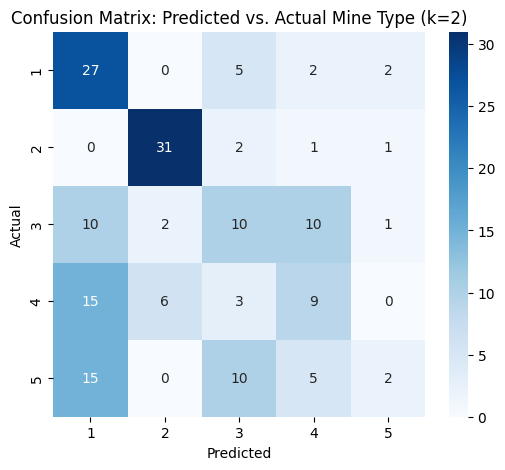

              precision    recall  f1-score   support

           1       0.40      0.75      0.52        36
           2       0.79      0.89      0.84        35
           3       0.33      0.30      0.32        33
           4       0.33      0.27      0.30        33
           5       0.33      0.06      0.11        32

    accuracy                           0.47       169
   macro avg       0.44      0.45      0.42       169
weighted avg       0.44      0.47      0.43       169



In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns

# fitting the optimal model (k=2) and predicting on the test set
model = KNeighborsClassifier(n_neighbors=k_star)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# building the confusion table
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = 'Actual'
cm_df.columns.name = 'Predicted'

print(cm_df)
print()
print('Overall accuracy:', accuracy_score(y_test, y_pred))

# visualizing the same confusion table as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs. Actual Mine Type (k=2)')
plt.show()

# precision, recall, and F1 by class, plus macro/weighted averages
print(classification_report(y_test, y_pred))

The overall accuracy is similar to what's reported above, at approximately 47%. The model is most accurate for mine type 2, correctly identifying 31 out of 35 cases (89%). Mine type 1 comes in second, correctly identifying 27 out of 36 cases (75%). We can see this by reading down the diagonal of the matrix, which shows the number of correct predictions for each class. However, mine type 5 performs much worse, with only 2 out of 32 cases identified accurately. The majority of the remaining mine type 5 cases are incorrectly predicted as mine type 1 or mine type 3. Mine types 3 and 4 also perform poorly, with roughly 30% and 27% accuracy respectively, and both are frequently misclassified as mine type 1 as well. This suggests that mine type 1 tends to dominate the neighbor pool across several classes, pulling votes away from their correct labels and contributing to a skewed, uneven predictive model.

**Q2.5**

If I were advising someone on using this model in practice, I wouldn't recommend trusting it as is. For mine type 1, the model correctly identifies 75% of actual type 1 mines (recall), but only 40% of what it labels as type 1 is actually type 1 (precision), since types 3, 4, and 5 are frequently misclassified into that bucket. This means a "type 1" label is more likely wrong than right, so it shouldn't be trusted at face value, even though its F1 score of 0.52 looks moderate on paper. Mine type 2 is the one prediction I would trust, with both precision and recall above 0.79, likely driven by its distinctly higher average voltage. Mine types 3, 4, and 5 are unreliable in both directions, with F1 scores of 0.32, 0.30, and 0.11 respectively, type 5 in particular is barely functioning as a predictor, catching only 6% of actual type 5 cases. For these three types, I'd recommend manual verification every time rather than relying on the model's output directly, and I'd flag type 5 specifically as a case where the model provides almost no reliable signal at all.

### *Reflection on AI assistance
In your own words without generative AI.

The main improvements focused on strengthening evaluation and validation rather than fixing errors in the original logic, since the core split, scaling, and k-selection methodology was already correct. For Q4, I added classification_report to get precision, recall, and F1 by class instead of hand-calculating individual numbers, and added a heatmap to visualize the confusion matrix pattern I had already described in words. For Q3, I added a comparison between uniform and distance-weighted voting, and cross-validated the k selection across the training set to confirm k=2 wasn't just an artifact of one particular train/test split. For Q5, I incorporated the new precision, recall, and F1 figures into my existing written advice, which added concrete numbers, like type 5's 0.11 F1 score, that my original answer didn't have. One AI limitation worth noting is that Claude didn't have access to our class slide deck initially, so some suggestions, like cross-validation, were general data science practices rather than methods explicitly taught in class. I verified the final solution by running all suggested code against the actual dataset and checking that new numbers, like the 40% precision calculation, matched my own manual calculations before incorporating them. My remaining concern is whether a better methodology exists beyond what was suggested, since AI assistance can introduce redundancy rather than genuine efficiency if suggestions are added without fully evaluating whether they add real value, so I tried to verify each addition actually strengthened the analysis rather than just adding more output.